## Probe Based Concept Vectors

This notebook reads the activation vectors in the probes trained by the script `train_probes.py` and saves them as normalized concept vectors.

It also performs a PCA dimensionality reduction on them.

In [1]:
model_name = 'qwen' #'qwen', 'intern' or 'gemma'

#### Import and utilities

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from ast import literal_eval # to get dict/list from csv
import pickle
import hydra
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
plt.rcParams['figure.constrained_layout.use'] = True 

import pyrootutils,sys
pyrootutils.setup_root('.',cwd=True,pythonpath=False)
sys.path.append('./src')

In [3]:
hydra.core.global_hydra.GlobalHydra.instance().clear()
hydra.initialize("config")
cfg = hydra.compose("activations_gen", overrides=[dict(qwen='+experiment=bal_qwen7b',
                                                       intern='+experiment=bal_internvl8b',
                                                       gemma='+experiment=bal_gemma12b')[model_name],
                                                  'probe=attn_single'
                                                  ])
probelabel = 'mmp' #layer used to read hidden activations (defined in config)

/tmp/ipykernel_2609579/165392830.py:2: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  hydra.initialize("config")


In [4]:
colors=cfg.dataset.COLORS.copy()
shapes=cfg.dataset.SHAPES.copy()
marker_shapes = ["\U000025A0","\U000025B2","\U000025CF","\U00002B1F","\U00002605","\U00002764"]

def simmatrix(V):
  'returns a matrix of cosine similarities'
  n=V.shape[0]
  sims = torch.empty(n,n)
  for i in range(n):
    sims[i]=torch.cosine_similarity(V,V[i])
  return sims

In [5]:
## Define colors and shapes
colors=cfg.dataset.COLORS.copy()
shapes=cfg.dataset.SHAPES.copy()
marker_shapes = ["\U000025A0","\U000025B2","\U000025CF","\U00002B1F","\U00002605","\U00002764"]

In [6]:
cfg.dataset

{'DATASET_TYPE': 'colshape_unbalanced', 'DATAPATH': './data/', 'DATASET_NAME': 'cs_bal_1t', 'REPEATS': 1, 'N_distractors': [8, 16, 24, 32, 40, 2, 4], 'P_interfere': [0, 0.25, 0.5, 0.75, 1.0], 'N_unique_distractors': [4], 'COLORS': ['red', 'green', 'blue', 'yellow', 'orange', 'purple'], 'COLORS_DICT': {'red': [228, 26, 28], 'green': [77, 175, 74], 'blue': [55, 126, 184], 'yellow': [255, 215, 0], 'orange': [255, 127, 0], 'purple': [152, 78, 163]}, 'SHAPES': ['square', 'triangle', 'circle', 'pentagon', 'star', 'heart'], 'constants': {'CANVAS_SIZE': [448, 448], 'STENCIL_SIZE': 32}, 'generate_metadata_function': {'_target_': 'vlm_datasets.shapecol_unbal.generate_metadata', '_partial_': True}, 'make_image_function': {'_target_': 'vlm_datasets.shapecol_unbal.make_image_from_metadata', '_partial_': True}}

In [ ]:
## function to plot vector similarities and their distributions
samecol = []
sameshape = []
different = []
for i in range(36):
  for j in range(i):
    if (i//6) == (j//6):
      samecol.append(i*36+j)
    elif i%6 == (j%6):
      sameshape.append(i*36+j)
    else:
      different.append(i*36+j)

labellist = []
for color in colors:
  for shape in shapes:
    labellist.append(color[:3]+' '+shape[:3])
def plotsims(sims, template_label=None, model_name = None):
  plt.close('all')
  fig,ax = plt.subplots(dpi=300,figsize=(6,7),
                        nrows = 2,height_ratios=(6,1)
  layout='tight')
  
  fig.tight_layout(h_pad=.1)
  markerlabels = []
  for i in range(6):
    for j in range(6):
      markerlabels.append(f'${marker_shapes[j]}$')
      ax[0].scatter(i*6+j+0.5,36.8,s=50,
                    clip_on=False,
                    marker=f'${marker_shapes[j]}$',
                    color=[c/255. for c in cfg.dataset.COLORS_DICT[colors[i]]])
      ax[0].scatter(-0.8,i*6+j+0.5,s=50,
                    clip_on=False,
                    marker=f'${marker_shapes[j]}$',
                    color=[c/255. for c in cfg.dataset.COLORS_DICT[colors[i]]])
  simsfl = sims.flatten()
  kwargs = dict(bins=100,range=(-1.,1.),density=True)


  ax[1].hist(simsfl[samecol],label='Same color',**kwargs,alpha=0.4,edgecolor='C0')
  ax[1].hist(simsfl[sameshape],label='Same shape',**kwargs,alpha=0.4,edgecolor='C1')
  ax[1].hist(simsfl[different],label='Both different',**kwargs,alpha=0.4,edgecolor='C2')

  ax[1].hist(simsfl[samecol],histtype='step',**kwargs,edgecolor='C0',linewidth=1.)
  ax[1].hist(simsfl[sameshape],histtype='step',**kwargs,edgecolor='C1',linewidth=1.)
  ax[1].hist(simsfl[different],histtype='step',**kwargs,edgecolor='C2',linewidth=1.)
  ax[1].set_xlim(-1,1)
  ax[1].set_xticklabels([])
  ax[1].tick_params(axis='both', which='both', length=0, labelleft=False)
  ax[1].legend(loc='upper left')
  ax[1].grid(False)
  
  cax = ax[1].inset_axes([0.,-.23,1,.15])
  sns.heatmap(sims,
              square=True,
              vmin=-1,vmax=1,
              linewidths=0.05,
              cbar=True, cbar_ax=cax,
              cbar_kws=dict(orientation='horizontal',label='Cosine similarity'),
              cmap='vlag',ax=ax[0])
  cax.xaxis.set_ticks_position('both')
  for spine in cax.spines.values():
    spine.set_visible(True)
    spine.set_lw(0.5)
  for spine in ax[0].spines.values():
    spine.set_visible(True)
    spine.set_lw(0.5)

  ax[0].set_yticks(torch.arange(36)+0.5,[])
  ax[0].set_xticks(torch.arange(36)+0.5,[])
  tempnicelabel= {
    'centroid':'Centroid-Based',
    'probe PCA':'Probe-Based (PCA)',
    'probe': 'Probe-Based (Raw)'
  }[template_label]
  nicename = {
    "qwen": 'Qwen 2.5 7B',
    'intern':'InternVL 2.5 8B',
    'gemma': 'Gemma 3 12B'
  }[model_name]
  ax[0].set_title(f'{nicename} - {tempnicelabel} Concept Vectors')

  return fig,ax

#### Probe-based
Here we load the parameters from trained probes, plot their pairwise similarity matrix and save them as normalized concept vectors

In [8]:
takeprobesdir=f"./outputs/{cfg.model.model_name}/{cfg.dataset.DATASET_NAME}/mmp_probes"
#takeprobesdir=f"./outputs/Gemma3_12B/bin_class/{cfg.dataset.DATASET_NAME}/mmp_probes"


### LOAD CONJUNCTIVE PROBES
# saved in files such as 'redsquare_notest.nn'
conj_attn_proj = []
conj_attn_bias = []
last_mult = []
last_bias = []
conj_labellist = []
for i,color in enumerate(colors[:]):
  for j, shape in enumerate(shapes):
    statedict = torch.load(os.path.join(takeprobesdir,color+shape+f'_{cfg.probe.versionlabel}.nn'))
    conj_attn_proj.append(statedict['attn_proj.weight'].detach().squeeze())#,statedict['attn_proj.bias'])) )
    #conj_last_proj.append(torch.cat( (statedict['last_proj.weight'].squeeze(),statedict['last_proj.bias'])))
    conj_labellist.append(color[:3]+' '+shape[:3])
    conj_attn_bias.append(statedict['attn_proj.bias'])
    last_mult.append(statedict['last_mult'])
    last_bias.append(statedict['last_bias'])
conj_attn_proj=torch.stack(conj_attn_proj).to(torch.double)

In [9]:
concept_vectors = F.normalize(conj_attn_proj,dim=1)

In [10]:
datapath = os.path.join('.','outputs',cfg.model.model_name)

torch.save(concept_vectors.to(torch.float),
           os.path.join(datapath,f'colorshape_cv_probe.pt'))

In [11]:
probe_sims = simmatrix(concept_vectors)

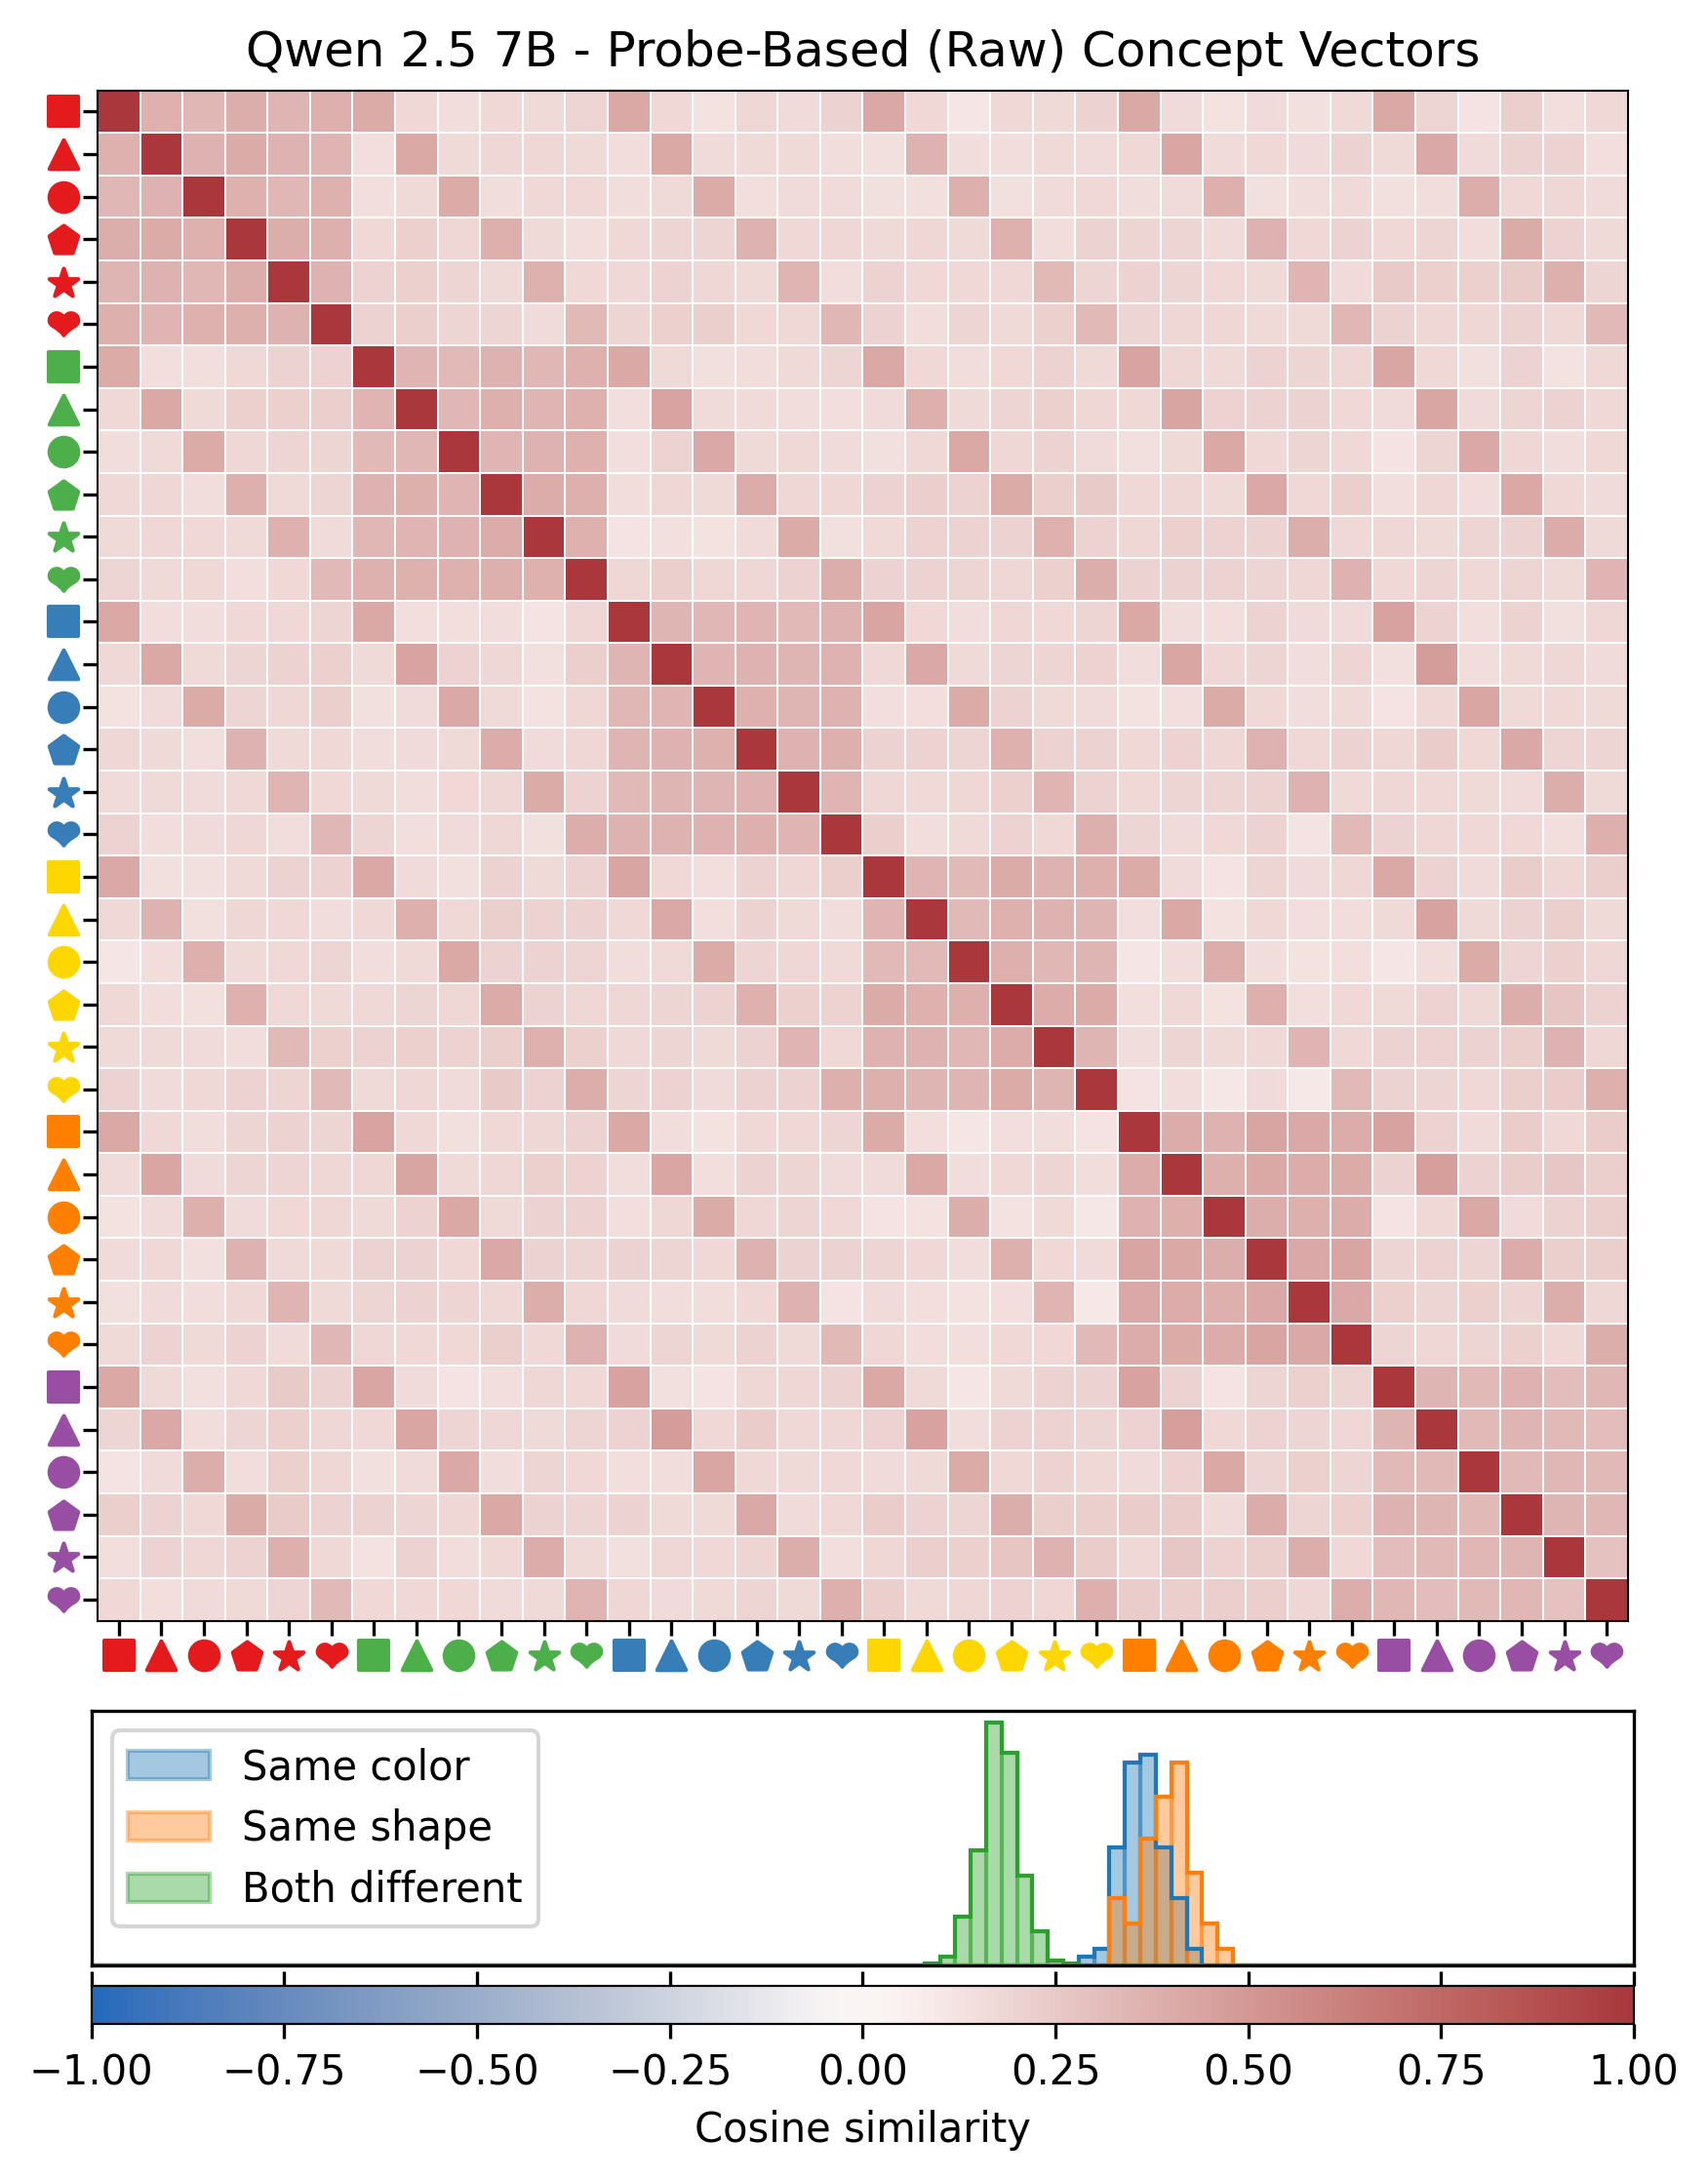

In [12]:
fig,ax = plotsims(probe_sims,'probe',model_name)
fig.savefig(f'./outputs/compositionality_plots/{model_name}_probe_simmatrix.pdf',bbox_inches='tight')

#### PCA Structural Regularization

In [13]:
u,s,v = torch.pca_lowrank(conj_attn_proj,q=36,center=True)

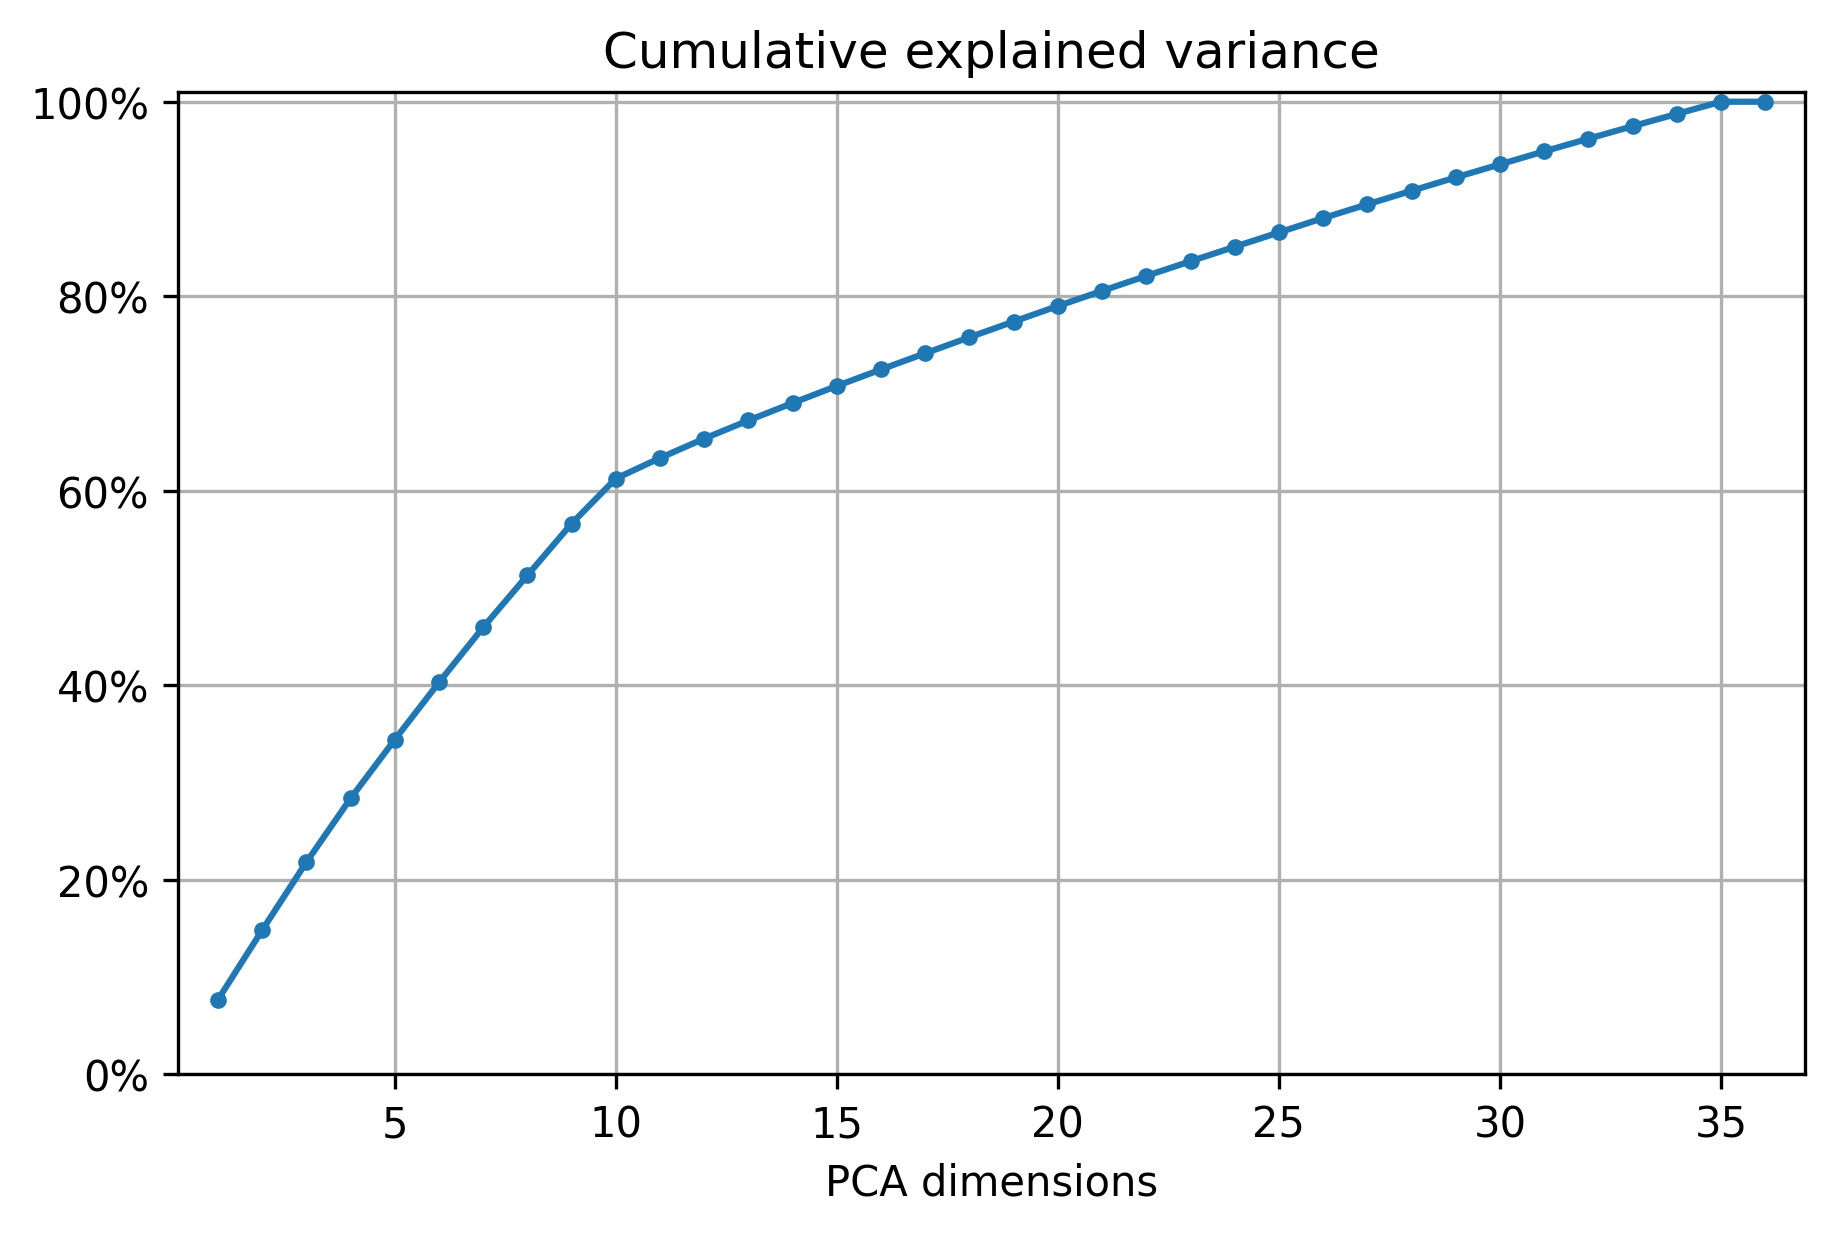

In [14]:
plt.close('all')
fig,ax = plt.subplots(figsize=(6,4),dpi=300)
ax.plot(np.arange(1,37),(s**2/(s**2).sum()).cumsum(axis=0)*100,
        '.-')

ax.set_ylim(0,101)
ax.set_xlim(0.1,36.9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Cumulative explained variance')
ax.set_xlabel('PCA dimensions')
#ax.legend()
ax.grid()

In [15]:
cv_pca = F.normalize(concept_vectors@v[:,0:10]@v[:,0:10].T,dim=1)

In [16]:
torch.save(cv_pca.to(torch.float),
           os.path.join(datapath,f'colorshape_cv_probepca.pt'))

In [17]:
sims_pca = simmatrix(cv_pca)

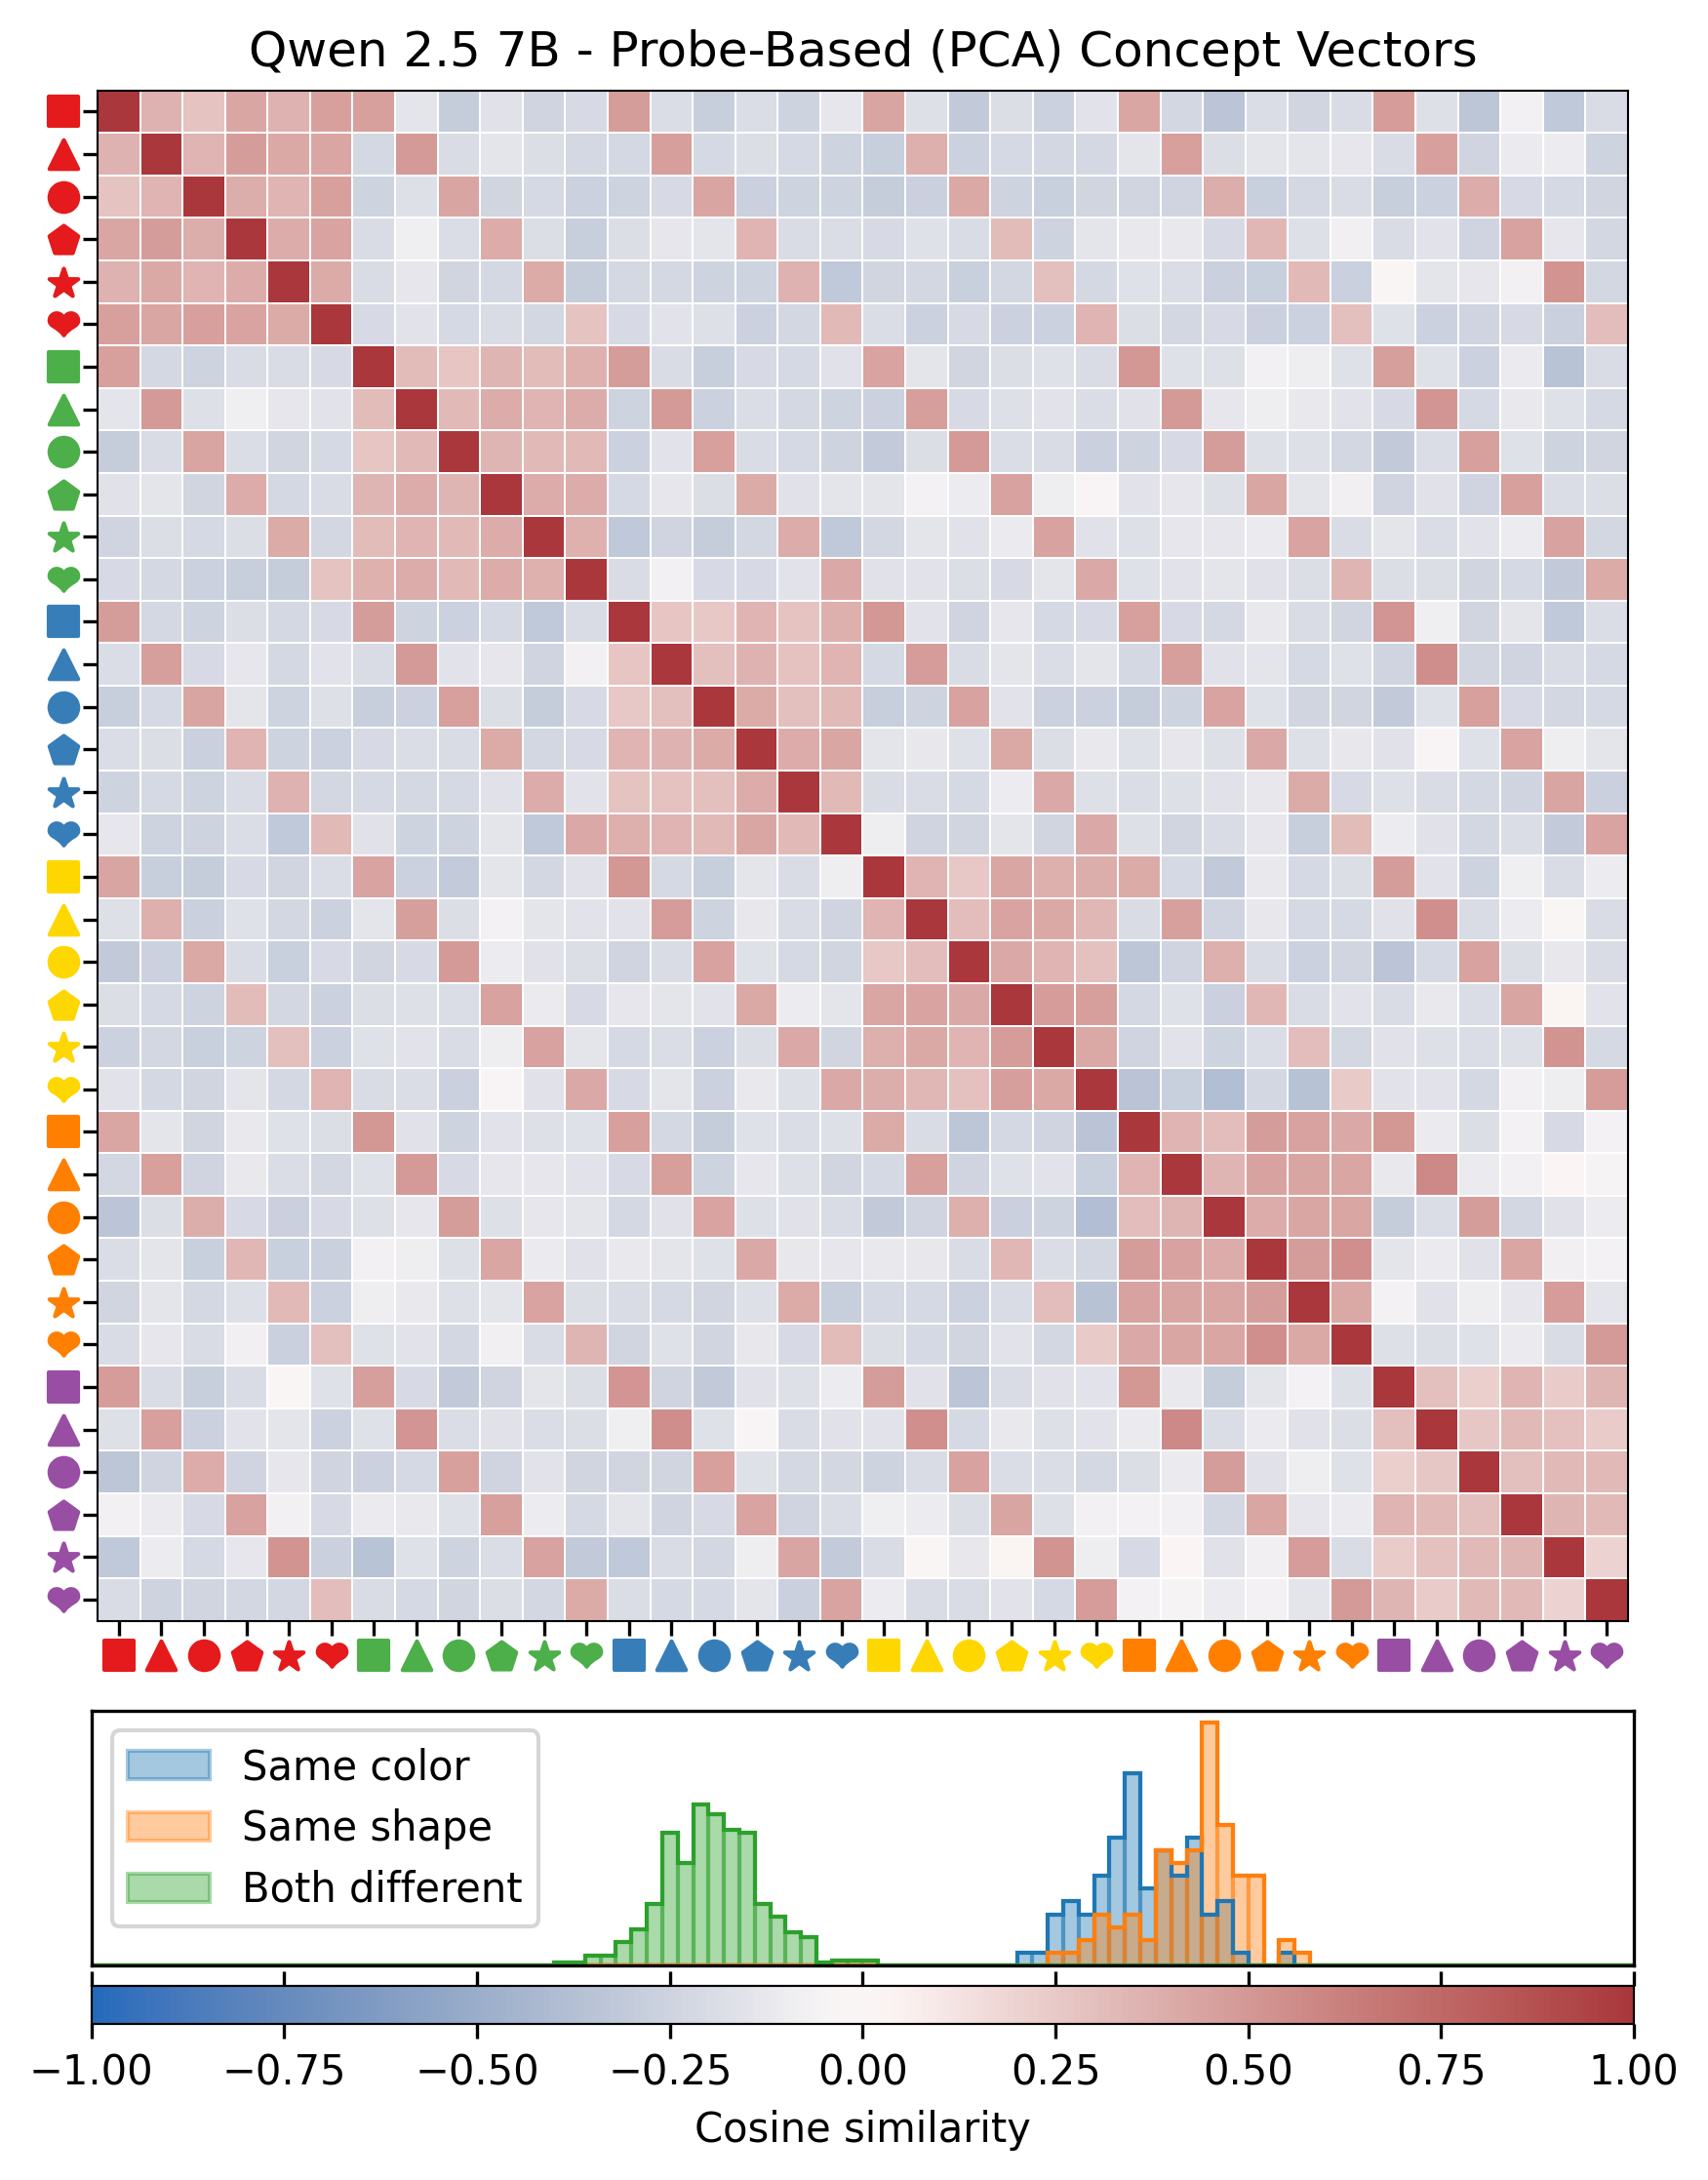

In [18]:
fig,ax = plotsims(sims_pca,'probe PCA',model_name)
fig.savefig(f'./outputs/compositionality_plots/{model_name}_pca_simmatrix.pdf',bbox_inches='tight')